# 5. Customer Segmentation — Clustering

## Objective

Segment tourism users into meaningful groups based on their
historical tourism behavior.

### Approach

- Build user-level behavioral features
- Scale the features
- Determine an appropriate number of clusters
- Apply K-Means clustering
- Analyze and interpret the resulting user segments

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [17]:
df = pd.read_csv("tourism_cleaned_engineered.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (52930, 24)


,TransactionId,UserId,VisitYear,VisitMonth,VisitModeId,AttractionId,Rating,ContinentId,RegionId,CountryId,...,Attraction,AttractionAddress,AttractionType,Continent,Region,Country,CityName,user_avg_rating,attraction_avg_rating,user_visit_count
0,3,70456,2022,10,2,640,5,5,21,163,...,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Europe,Western Europe,United Kingdom,Guildford,5.0,4.267086,1
1,8,7567,2022,10,4,640,5,2,8,48,...,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,America,Northern America,Canada,Ontario,5.0,4.267086,1
2,9,79069,2022,10,3,640,5,2,9,54,...,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,America,South America,Brazil,Brazil,5.0,4.267086,1
3,10,31019,2022,10,3,640,3,5,17,135,...,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Europe,Central Europe,Switzerland,Zurich,3.0,4.267086,2
4,15,43611,2022,10,2,640,3,5,21,163,...,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Europe,Western Europe,United Kingdom,Manchester,3.0,4.267086,3


In [18]:
print("Columns:")
print(df.columns.tolist())

Columns:
['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitModeId', 'AttractionId', 'Rating', 'ContinentId', 'RegionId', 'CountryId', 'CityId', 'VisitMode', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress', 'AttractionType', 'Continent', 'Region', 'Country', 'CityName', 'user_avg_rating', 'attraction_avg_rating', 'user_visit_count']


In [19]:
user_features = df.groupby("UserId").agg(
    total_visits=("TransactionId", "count"),
    unique_attractions=("AttractionId", "nunique"),
    avg_rating=("Rating", "mean"),
    unique_visit_modes=("VisitModeId", "nunique")
).reset_index()

print("User Feature Shape:", user_features.shape)
user_features.head()

User Feature Shape: (33530, 5)


,UserId,total_visits,unique_attractions,avg_rating,unique_visit_modes
0,14,3,2,4.666667,1
1,16,10,5,4.700000,4
2,20,1,1,4.000000,1
3,23,1,1,5.000000,1
4,25,1,1,5.000000,1


In [20]:
features = [
    "total_visits",
    "unique_attractions",
    "avg_rating",
    "unique_visit_modes"
]

X = user_features[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled Feature Shape:", X_scaled.shape)

Scaled Feature Shape: (33530, 4)


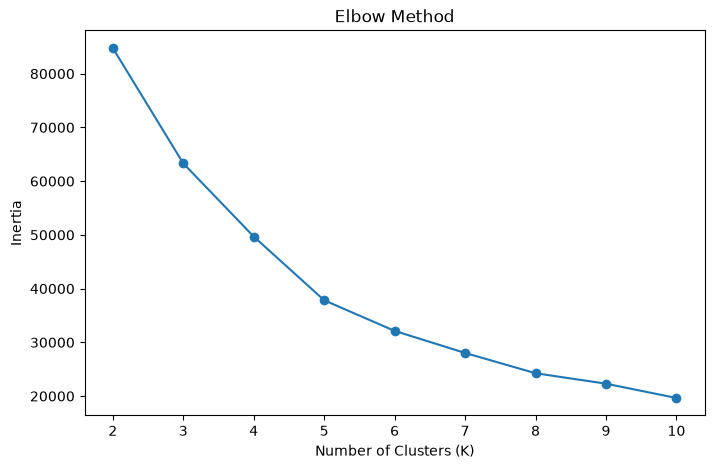

In [21]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(K_range)
plt.show()

In [22]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

silhouette_results = pd.DataFrame({
    "K": list(K_range),
    "Silhouette Score": silhouette_scores
})

print(silhouette_results)

    K  Silhouette Score
0   2          0.616341
1   3          0.510704
2   4          0.566891
3   5          0.581982
4   6          0.673151
5   7          0.692282
6   8          0.697688
7   9          0.725360
8  10          0.738906


In [23]:
optimal_k = 5

kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

user_features["Cluster"] = kmeans_final.fit_predict(X_scaled)

print("Clustering completed.")
print("\nCluster Counts:")
print(user_features["Cluster"].value_counts().sort_index())

Clustering completed.

Cluster Counts:
Cluster
0    19760
1     2527
2     5295
3      576
4     5372
Name: count, dtype: int64


In [24]:
cluster_profile = user_features.groupby("Cluster")[[
    "total_visits",
    "unique_attractions",
    "avg_rating",
    "unique_visit_modes"
]].mean().round(2)

print(cluster_profile)

         total_visits  unique_attractions  avg_rating  unique_visit_modes
Cluster                                                                  
0                1.08                1.00        4.59                1.00
1                2.80                2.10        4.19                2.09
2                1.14                1.03        2.55                1.00
3                7.63                4.49        4.15                2.64
4                2.60                2.26        4.20                1.00


In [25]:
cluster_distribution = (
    user_features["Cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_distribution.columns = ["Cluster", "Users"]

cluster_distribution["Percentage"] = (
    cluster_distribution["Users"] /
    len(user_features) * 100
).round(2)

print(cluster_distribution)

   Cluster  Users  Percentage
0        0  19760       58.93
1        1   2527        7.54
2        2   5295       15.79
3        3    576        1.72
4        4   5372       16.02


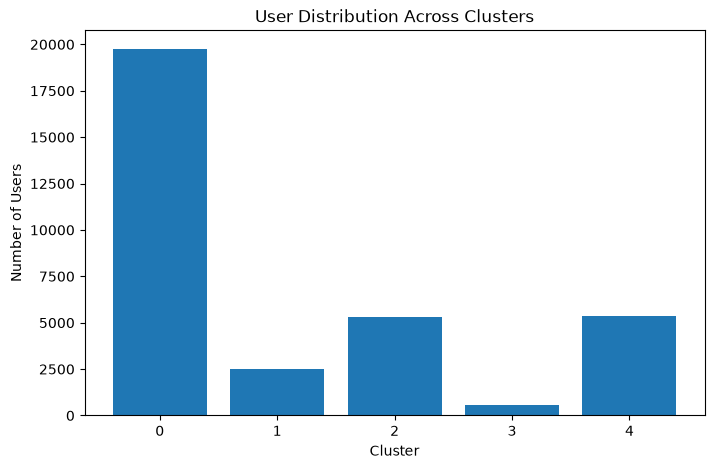

In [26]:
plt.figure(figsize=(8, 5))

plt.bar(
    cluster_distribution["Cluster"].astype(str),
    cluster_distribution["Users"]
)

plt.xlabel("Cluster")
plt.ylabel("Number of Users")
plt.title("User Distribution Across Clusters")

plt.show()

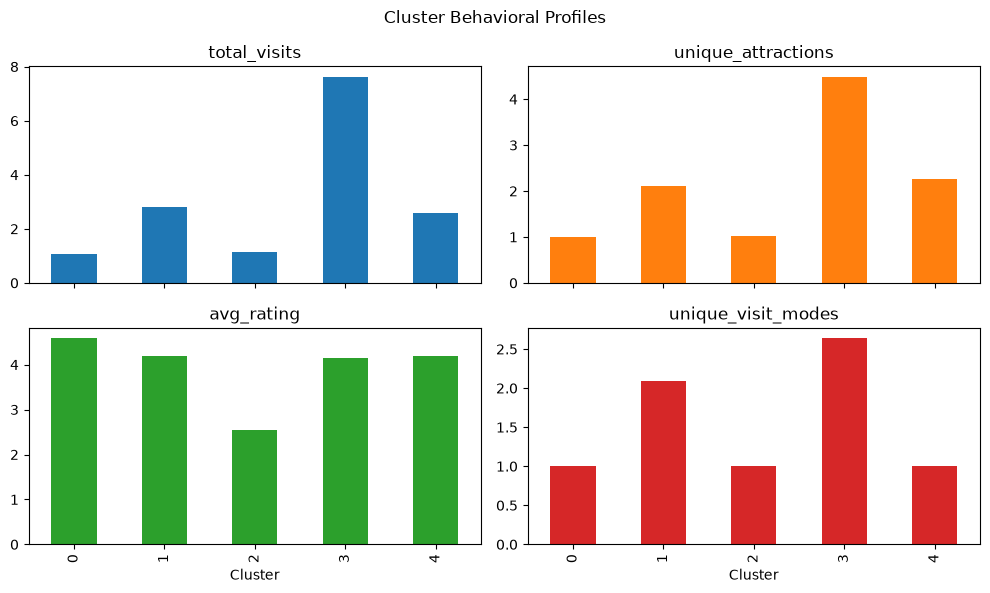

In [27]:
cluster_profile.plot(
    kind="bar",
    figsize=(10, 6),
    subplots=True,
    layout=(2, 2),
    legend=False
)

plt.suptitle("Cluster Behavioral Profiles")
plt.tight_layout()
plt.show()

In [28]:
for cluster in sorted(user_features["Cluster"].unique()):
    print(f"\nCluster {cluster}")
    
    print(
        user_features[
            user_features["Cluster"] == cluster
        ]
        .sort_values("total_visits", ascending=False)
        .head(5)
    )


Cluster 0
       UserId  total_visits  unique_attractions  avg_rating  \
8123    23156             3                   1    4.666667   
10150   28836             3                   1    5.000000   
15090   41310             3                   1    4.333333   
15031   41165             3                   1    4.666667   
4955    14477             3                   1    3.666667   

       unique_visit_modes  Cluster  
8123                    1        0  
10150                   1        0  
15090                   1        0  
15031                   1        0  
4955                    1        0  

Cluster 1
       UserId  total_visits  unique_attractions  avg_rating  \
17562   47538             9                   1    4.000000   
4145    12414             9                   1    4.888889   
21856   58374             9                   1    4.888889   
24833   65768             9                   1    4.000000   
23512   62483             9                   1    4.000000   

In [29]:
import joblib

cluster_names = {
    0: "Occasional High-Rating Visitors",
    1: "Multi-Mode Travelers",
    2: "Low-Satisfaction Visitors",
    3: "Frequent & Diverse Travelers",
    4: "Repeat Visitors"
}

user_features["Segment"] = user_features["Cluster"].map(cluster_names)

joblib.dump(kmeans_final, "kmeans_clustering_model.pkl")
joblib.dump(scaler, "clustering_scaler.pkl")
joblib.dump(features, "clustering_feature_columns.pkl")
joblib.dump(cluster_names, "cluster_names.pkl")

print("Clustering model and supporting files saved successfully.")

Clustering model and supporting files saved successfully.


## Clustering Results & Key Findings

K-Means clustering was used to segment tourism users based on their
historical behavioral patterns.

### Features Used

- Total visits
- Number of unique attractions visited
- Average rating given
- Number of unique visit modes

The features were standardized using `StandardScaler` before applying
K-Means clustering.

### Cluster Selection

The Elbow Method suggested a reasonable bend around K=5. Although the
Silhouette Score increased for larger values of K, K=5 was selected to
maintain a balance between cluster quality and interpretability.

### Identified User Segments

| Cluster | Segment | Users | Percentage |
|---|---|---:|---:|
| 0 | Occasional High-Rating Visitors | 19,760 | 58.93% |
| 1 | Multi-Mode Travelers | 2,527 | 7.54% |
| 2 | Low-Satisfaction Visitors | 5,295 | 15.79% |
| 3 | Frequent & Diverse Travelers | 576 | 1.72% |
| 4 | Repeat Visitors | 5,372 | 16.02% |

### Segment Characteristics

- **Cluster 0:** Mostly occasional visitors with approximately one visit
  and relatively high average ratings.
- **Cluster 1:** Users with multiple visits who use different visit modes.
- **Cluster 2:** Occasional visitors with significantly lower average
  ratings, representing a low-satisfaction segment.
- **Cluster 3:** The most active and diverse travelers, with the highest
  number of visits, attractions, and visit modes.
- **Cluster 4:** Repeat visitors who visit multiple attractions but
  generally use a single visit mode.

### Conclusion

The clustering analysis identified five distinct behavioral segments
among tourism users. These segments can support targeted tourism
recommendations, customer analysis, and personalized engagement
strategies.